# Retrain ImageCodec on Euclid Images

This notebook demonstrates how to retrain the ImageCodec using Euclid images.
The codec is loaded with HSC modality and trained using MSE loss between input and reconstructed output.

## Imports and Setup

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

from aion.codecs import ImageCodec
from aion.codecs.config import HF_REPO_ID
from aion.modalities import HSCImage
from aion.datasets import EuclidDESIDataset, collate_modalities

## Configuration

In [3]:
CACHE_DIR = "../data/"
MAX_ENTRIES = 100
BATCH_SIZE = 4
LEARNING_RATE = 1e-4
NUM_EPOCHS = 5
SAVE_DIR = "./retrained_codec"

device = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f"Using device: {device}")
print(f"Max entries: {MAX_ENTRIES}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Epochs: {NUM_EPOCHS}")

Using device: cpu
Max entries: 100
Batch size: 4
Learning rate: 0.0001
Epochs: 5


/home/wassim/micromamba/envs/AAI11/lib/python3.11/site-packages/torch/cuda/__init__.py:182: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


## Load Pre-trained ImageCodec

In [4]:
print("Loading ImageCodec with HSCImage modality...")
codec = ImageCodec.from_pretrained(HF_REPO_ID, modality=HSCImage)
codec = codec.to(device)
codec.eval()

print(f"Codec loaded successfully")
print(f"Codec device: {next(codec.parameters()).device}")

Loading ImageCodec with HSCImage modality...
Codec loaded successfully
Codec device: cpu


## Load Euclid-DESI Dataset

In [5]:
print(f"Loading dataset from {CACHE_DIR}...")
dataset = EuclidDESIDataset(
    cache_dir=CACHE_DIR,
    mode="streaming",
    device=device,
    max_entries=MAX_ENTRIES,
    split='train'
)

loader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_modalities
)

print(f"Dataset has {len(dataset)} samples")
print(f"DataLoader created with {len(loader)} batches")

Loading dataset from ../data/...
Loaded 100 samples from disk: ../data/euclid_desi_train
Dataset has 100 samples
DataLoader created with 25 batches


## Training Setup

In [6]:
optimizer = torch.optim.Adam(codec.parameters(), lr=LEARNING_RATE)
criterion = torch.nn.MSELoss()

print(f"Optimizer: Adam with lr={LEARNING_RATE}")
print(f"Loss function: MSELoss")
print(f"Number of trainable parameters: {sum(p.numel() for p in codec.parameters() if p.requires_grad):,}")

Optimizer: Adam with lr=0.0001
Loss function: MSELoss
Number of trainable parameters: 70,058,592


## Training Loop

In [7]:
from aion.codecs.preprocessing.image import CenterCrop

crop_96 = CenterCrop(crop_size=96)

training_losses = []

codec.train()

for epoch in range(NUM_EPOCHS):
    epoch_losses = []
    progress_bar = tqdm(loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}")
    
    for batch_idx, (rgb_image, euclid_image, desi_spectrum, z_redshift) in enumerate(progress_bar):
        euclid_original_flux = euclid_image.flux.clone()
        
        euclid_cropped_flux = crop_96(euclid_image.flux.to(device))
        
        euclid_as_hsc = HSCImage(flux=euclid_cropped_flux, bands=euclid_image.bands)
        
        optimizer.zero_grad()
        
        encoded = codec.encode(euclid_as_hsc)
        reconstructed = codec.decode(encoded, bands=euclid_image.bands)
        
        loss = criterion(reconstructed.flux, euclid_cropped_flux)
        
        loss.backward()
        optimizer.step()
        
        epoch_losses.append(loss.item())
        progress_bar.set_postfix({'loss': f'{loss.item():.6f}'})
    
    avg_epoch_loss = np.mean(epoch_losses)
    training_losses.append(avg_epoch_loss)
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} - Average Loss: {avg_epoch_loss:.6f}")

print("\nTraining complete!")

Epoch 1/5:   0%|          | 0/25 [00:00<?, ?it/s]

/home/wassim/Projects/NBody/AION/aion/datasets.py:296: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mask=torch.tensor(mask, dtype=torch.bool),


Epoch 1/5 - Average Loss: 0.011746


Epoch 2/5:   0%|          | 0/25 [00:00<?, ?it/s]

Epoch 2/5 - Average Loss: 0.000531


...

Epoch 3/5 - Average Loss: 0.000089


Epoch 4/5:   0%|          | 0/25 [00:00<?, ?it/s]

Epoch 4/5 - Average Loss: 0.000041


Epoch 5/5:   0%|          | 0/25 [00:00<?, ?it/s]

Epoch 5/5 - Average Loss: 0.000028

Training complete!


## Visualize Training Results

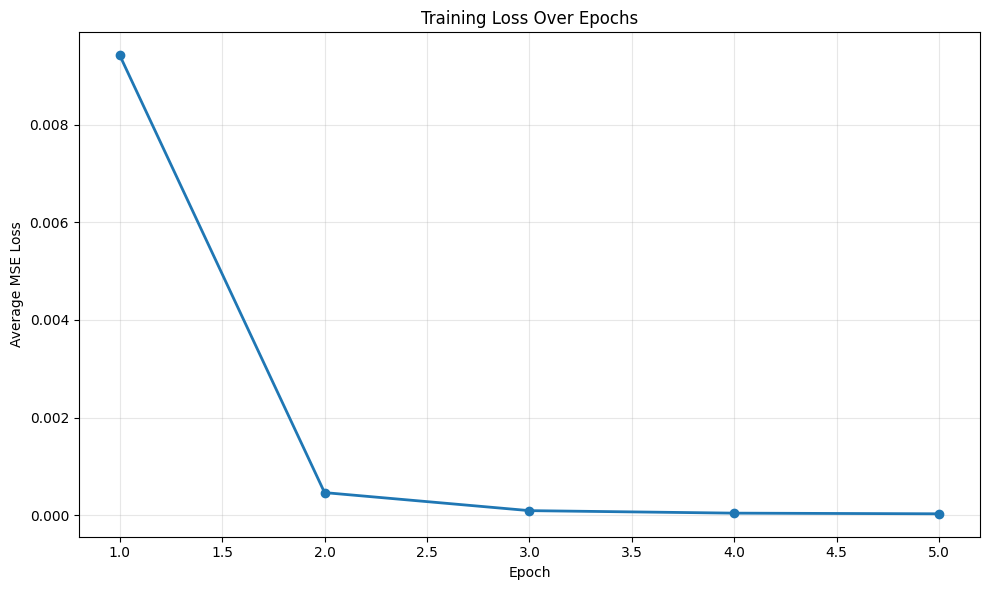

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, NUM_EPOCHS + 1), training_losses, marker='o', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Average MSE Loss')
plt.title('Training Loss Over Epochs')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Test Reconstruction Quality

In [8]:
from aion.codecs.preprocessing.image import CenterCrop

crop_96 = CenterCrop(crop_size=96)


codec.eval()

with torch.no_grad():
    test_batch = next(iter(loader))
    rgb_image, euclid_image, desi_spectrum, z_redshift = test_batch
    
    euclid_original_flux = euclid_image.flux.clone()
    
    euclid_cropped_flux = crop_96(euclid_image.flux.to(device))
    euclid_as_hsc = HSCImage(flux=euclid_original_flux, bands=euclid_image.bands)
    
    tokens = codec.encode(euclid_as_hsc)
    reconstructed = codec.decode(tokens, bands=euclid_image.bands)
    
    test_loss = criterion(reconstructed.flux, euclid_cropped_flux)
    print(f"Test reconstruction MSE: {test_loss.item():.6f}")

original_flux = euclid_image.flux.cpu()
cropped_flux = euclid_cropped_flux.cpu()
reconstructed_flux = reconstructed.flux.cpu()

Test reconstruction MSE: 0.028495


## Display Original vs Reconstructed Images

In [16]:
original_flux.shape

torch.Size([4, 4, 160, 160])

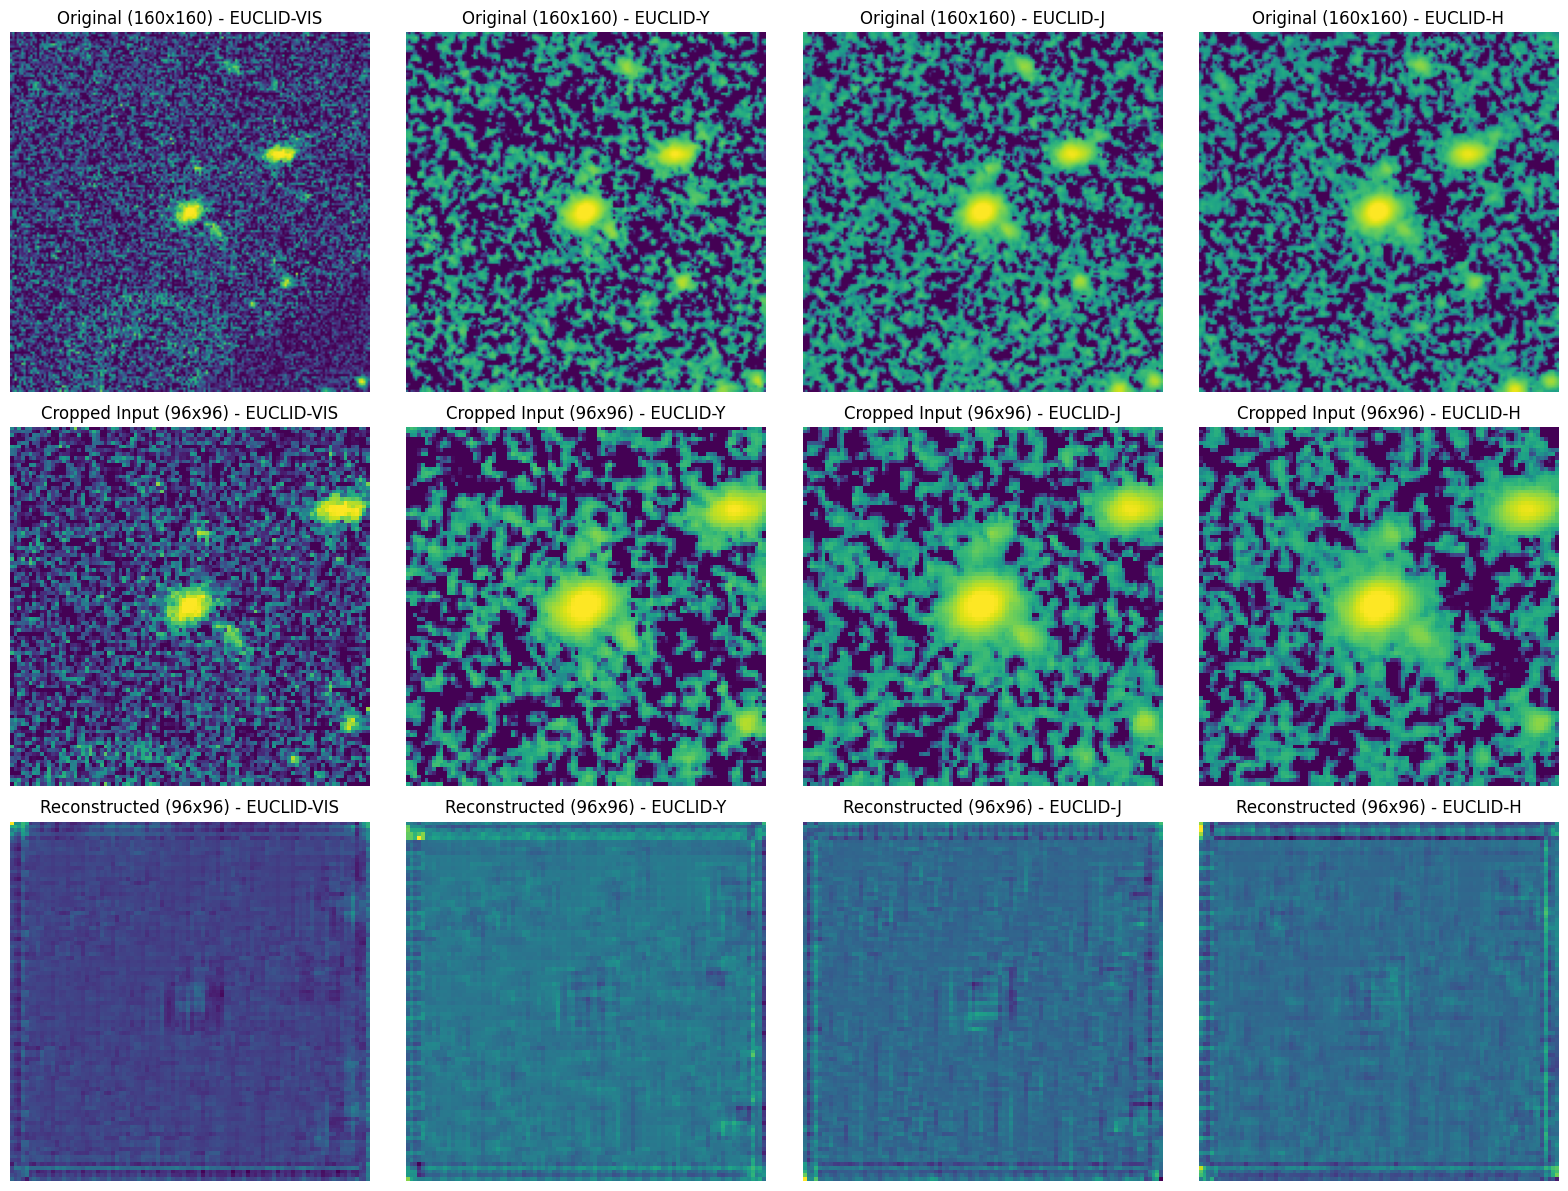

In [9]:
sample_idx = 0
num_bands = original_flux.shape[1]

fig, axes = plt.subplots(3, num_bands, figsize=(16, 12))

for band_idx in range(num_bands):
    orig_img = original_flux[sample_idx, band_idx].numpy()
    crop_img = cropped_flux[sample_idx, band_idx].numpy()
    recon_img = reconstructed_flux[sample_idx, band_idx].numpy()

    axes[0, band_idx].imshow(orig_img, cmap='viridis')
    axes[0, band_idx].set_title(f'Original (160x160) - {euclid_image.bands[band_idx]}')
    axes[0, band_idx].axis('off')
    
    axes[1, band_idx].imshow(crop_img, cmap='viridis')
    axes[1, band_idx].set_title(f'Cropped Input (96x96) - {euclid_image.bands[band_idx]}')
    axes[1, band_idx].axis('off')
    
    axes[2, band_idx].imshow(recon_img, cmap='viridis')
    axes[2, band_idx].set_title(f'Reconstructed (96x96) - {euclid_image.bands[band_idx]}')
    axes[2, band_idx].axis('off')

plt.tight_layout()
plt.show()

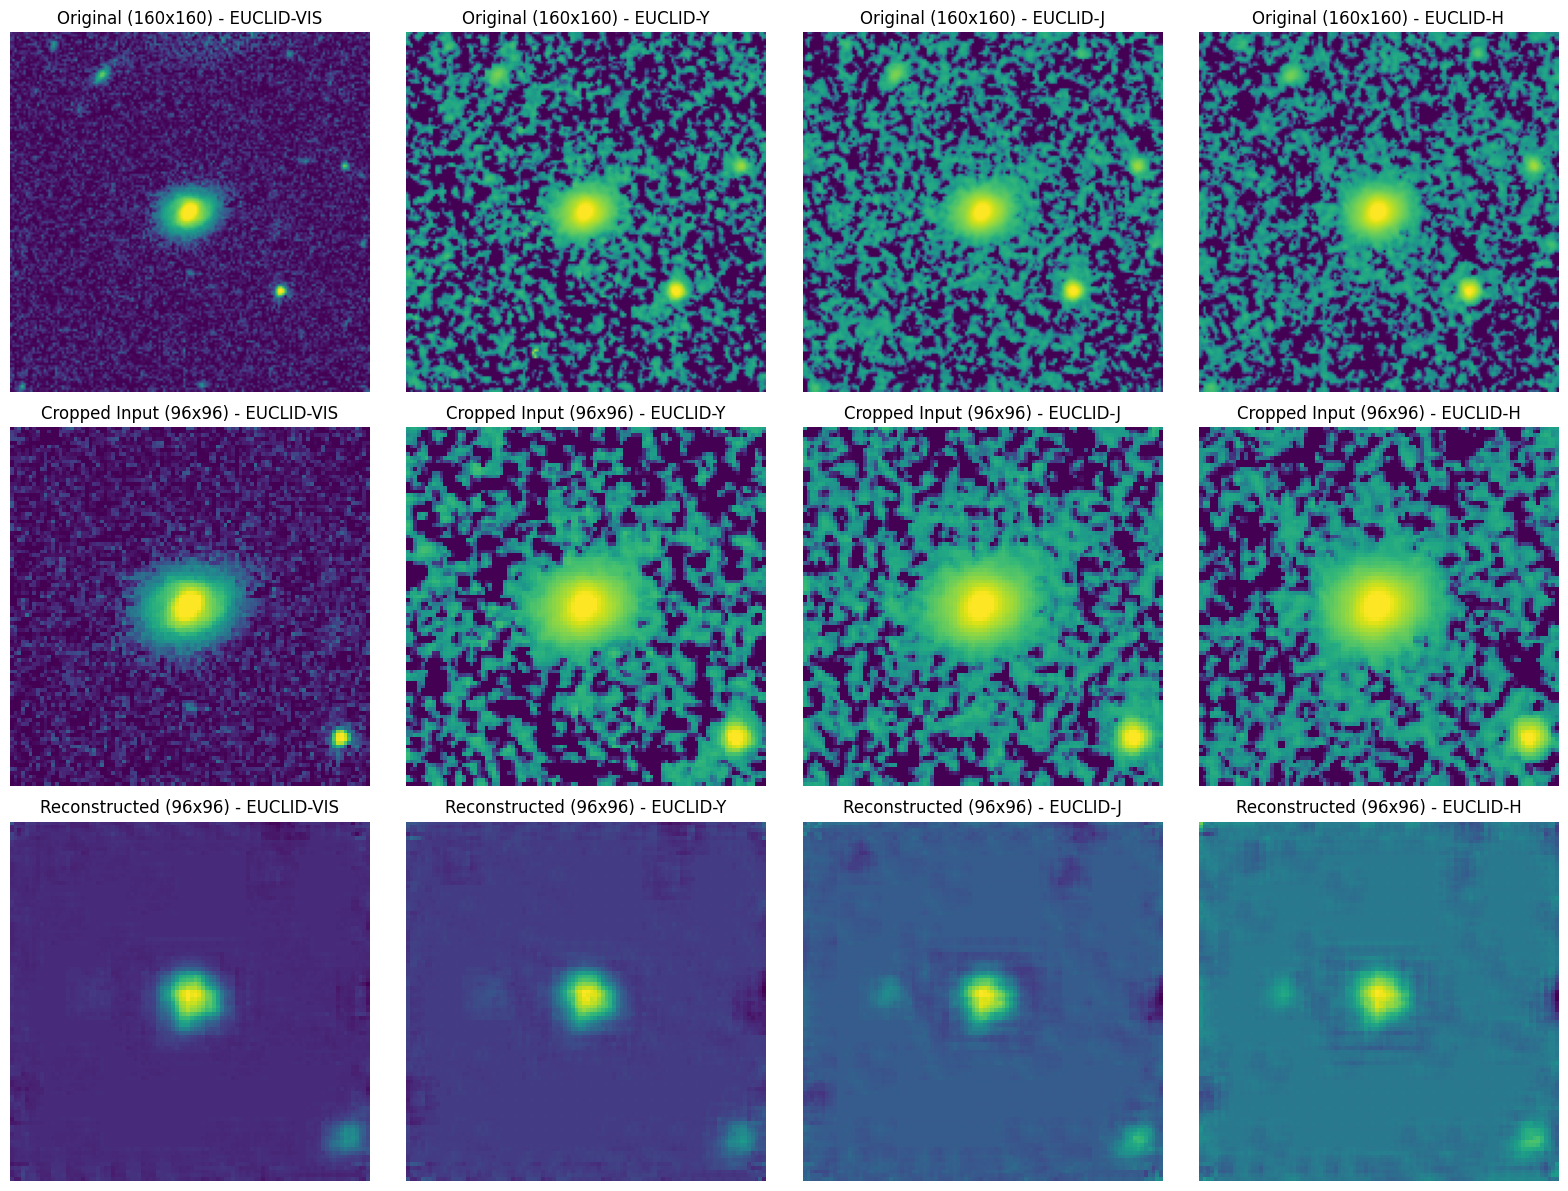

In [10]:
sample_idx = 0
num_bands = original_flux.shape[1]

fig, axes = plt.subplots(3, num_bands, figsize=(16, 12))

for band_idx in range(num_bands):
    orig_img = original_flux[sample_idx, band_idx].numpy()
    crop_img = cropped_flux[sample_idx, band_idx].numpy()
    recon_img = reconstructed_flux[sample_idx, band_idx].numpy()

    axes[0, band_idx].imshow(orig_img, cmap='viridis')
    axes[0, band_idx].set_title(f'Original (160x160) - {euclid_image.bands[band_idx]}')
    axes[0, band_idx].axis('off')
    
    axes[1, band_idx].imshow(crop_img, cmap='viridis')
    axes[1, band_idx].set_title(f'Cropped Input (96x96) - {euclid_image.bands[band_idx]}')
    axes[1, band_idx].axis('off')
    
    axes[2, band_idx].imshow(recon_img, cmap='viridis')
    axes[2, band_idx].set_title(f'Reconstructed (96x96) - {euclid_image.bands[band_idx]}')
    axes[2, band_idx].axis('off')

plt.tight_layout()
plt.show()

## Save Retrained Codec

In [ ]:
print(f"Saving retrained codec to {SAVE_DIR}...")
codec.save_pretrained(SAVE_DIR, modality=HSCImage)
print(f"Codec saved successfully to {SAVE_DIR}")
print(f"Codec files saved at: {SAVE_DIR}/codecs/{HSCImage.name}/")

Saving retrained codec to ./retrained_codec...


Codec saved successfully to ./retrained_codec
Codec files saved at: ./retrained_codec/codecs/image/
